# **Phishing Detection using Machine Learning**


Phishing is the fraudulent practice of impersonating reputable companies to access one's orivate information. Phishing has been an issue for quite some time. In 2021, the average click rate for a phishing campaign was 17.8%. Our task is to create a machine learning model that will help us classify emails as phishing scams or not.


Import libraries

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, pairwise_distances_argmin_min
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns

# **Understanding Dataset**

Read dataframe

In [20]:
fish = pd.read_csv('Phishing_Legitimate_full.csv')

fish.shape
fish.columns


Index(['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash',
       'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore',
       'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash',
       'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress',
       'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname',
       'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath',
       'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow',
       'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle',
       'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT',
       'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT',
       'PctExtNullSelfRedirectHyperl

As you can see there are 50 features and 10000 entries, notice the  Class_LABEL feature will be 1 if it is not scam and 0 otherwise. We will use supervised learning to fully utilize this feature.


In [21]:
fish.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


# **Preprocessing data**

Lets see how many missing entries are located in each feature

In [22]:
missing_data = fish.isna().sum().to_dict()
print("MISSING DATA IN COL:", missing_data)

MISSING DATA IN COL: {'id': 0, 'NumDots': 0, 'SubdomainLevel': 0, 'PathLevel': 0, 'UrlLength': 0, 'NumDash': 0, 'NumDashInHostname': 0, 'AtSymbol': 0, 'TildeSymbol': 0, 'NumUnderscore': 0, 'NumPercent': 0, 'NumQueryComponents': 0, 'NumAmpersand': 0, 'NumHash': 0, 'NumNumericChars': 0, 'NoHttps': 0, 'RandomString': 0, 'IpAddress': 0, 'DomainInSubdomains': 0, 'DomainInPaths': 0, 'HttpsInHostname': 0, 'HostnameLength': 0, 'PathLength': 0, 'QueryLength': 0, 'DoubleSlashInPath': 0, 'NumSensitiveWords': 0, 'EmbeddedBrandName': 0, 'PctExtHyperlinks': 0, 'PctExtResourceUrls': 0, 'ExtFavicon': 0, 'InsecureForms': 0, 'RelativeFormAction': 0, 'ExtFormAction': 0, 'AbnormalFormAction': 0, 'PctNullSelfRedirectHyperlinks': 0, 'FrequentDomainNameMismatch': 0, 'FakeLinkInStatusBar': 0, 'RightClickDisabled': 0, 'PopUpWindow': 0, 'SubmitInfoToEmail': 0, 'IframeOrFrame': 0, 'MissingTitle': 0, 'ImagesOnlyInForm': 0, 'SubdomainLevelRT': 0, 'UrlLengthRT': 0, 'PctExtResourceUrlsRT': 0, 'AbnormalExtFormActionR

# Scaling and Normalizing data
Since there is none, we can proceed to normalizing our entries.

In [23]:
# Scaling and Normalization
from sklearn.preprocessing import StandardScaler

# Drop the 'id' column and target variable
X = fish.drop(columns=['CLASS_LABEL', 'id'])  # Features
y = fish['CLASS_LABEL']  # Target

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled.head())

    NumDots  SubdomainLevel  PathLevel  UrlLength   NumDash  \
0  0.412023        0.550071   0.912273   0.052023 -0.585299   
1  0.412023        0.550071  -0.161179   2.209765 -0.585299   
2  0.412023        0.550071  -0.697905  -0.367538 -0.585299   
3  0.412023        0.550071   1.448999   0.261803 -0.263353   
4  0.412023       -0.781175   0.375547  -0.727162 -0.585299   

   NumDashInHostname  AtSymbol  TildeSymbol  NumUnderscore  NumPercent  ...  \
0          -0.254528 -0.017323    -0.115212      -0.289968   -0.118608  ...   
1          -0.254528 -0.017323    -0.115212       1.504391   -0.118608  ...   
2          -0.254528 -0.017323    -0.115212      -0.289968   -0.118608  ...   
3          -0.254528 -0.017323    -0.115212      -0.289968   -0.118608  ...   
4          -0.254528 -0.017323    -0.115212      -0.289968   -0.118608  ...   

   SubmitInfoToEmail  IframeOrFrame  MissingTitle  ImagesOnlyInForm  \
0          -0.384502      -0.717101     -0.182404          5.647543   
1   

# Feature Reduction

Since we have 48 features, let's reduce the amount of features so that our model can be more accurate and reduce overfitting

In [24]:
# Feature Selection/Reduction
# Calculate correlation with the target variable
correlation = fish.corr()['CLASS_LABEL'].sort_values(ascending=False)
print("Feature Correlation with CLASS_LABEL:\n", correlation)

# Set a threshold for correlation (e.g., > 0.1 or < -0.1)
relevant_features = correlation[(correlation > 0.1) | (correlation < -0.1)].index
print("Relevant Features Before Filtering:", relevant_features)

# Filter relevant features to include only those in X_scaled
relevant_features = [feature for feature in relevant_features if feature in X_scaled.columns]
print("Relevant Features After Filtering:", relevant_features)

# Filter dataset for relevant features
X_selected = X_scaled[relevant_features]





Feature Correlation with CLASS_LABEL:
 CLASS_LABEL                           1.000000
FrequentDomainNameMismatch            0.463956
PctNullSelfRedirectHyperlinks         0.342806
InsecureForms                         0.316380
NumDots                               0.294111
PctExtHyperlinks                      0.259728
NumSensitiveWords                     0.255208
PathLevel                             0.229450
AbnormalExtFormActionR                0.185799
UrlLengthRT                           0.169513
HostnameLength                        0.169157
NumDashInHostname                     0.150444
EmbeddedBrandName                     0.141790
IpAddress                             0.132291
MissingTitle                          0.116693
ExtMetaScriptLinkRT                   0.111150
DomainInSubdomains                    0.100452
TildeSymbol                           0.095864
RightClickDisabled                    0.074900
ExtFavicon                            0.069140
PctExtResourceUrlsRT 

# Removing Outliers

Now let's remove any outliers so that our model doesn't overfit.

In [25]:
# Outlier Detection and Removal
# Calculate Z-scores for each feature
z_scores = np.abs((X_selected - X_selected.mean()) / X_selected.std())

# Set threshold for Z-scores (adjust as needed)
threshold = 4  # Allow more variability
non_outliers = (z_scores < threshold).all(axis=1)

# Filter the dataset
X_cleaned = X_selected[non_outliers]

y_cleaned = y[non_outliers]

print("Original Data Shape:", X_selected.shape)
print("Data Shape After Outlier Removal:", X_cleaned.shape)

Original Data Shape: (10000, 24)
Data Shape After Outlier Removal: (7915, 24)


In [26]:
# Cleaned Dataset
# Combine cleaned features and target
preprocessed_data = pd.DataFrame(X_cleaned, columns=X_selected.columns)
print(preprocessed_data.head())
preprocessed_data['CLASS_LABEL'] = y_cleaned.values

# Save preprocessed data to a CSV file
preprocessed_data.to_csv('preprocessed_phishing_data.csv', index=False)

new_data = pd.read_csv('preprocessed_phishing_data.csv')
print("Preprocessing complete. Data saved to 'preprocessed_phishing_data.csv'.")


   FrequentDomainNameMismatch  PctNullSelfRedirectHyperlinks  InsecureForms  \
0                   -0.523806                      -0.435776       0.429923   
1                   -0.523806                      -0.435776       0.429923   
2                   -0.523806                      -0.435776       0.429923   
4                    1.909105                      -0.435776      -2.325996   
7                   -0.523806                      -0.435776       0.429923   

    NumDots  PctExtHyperlinks  NumSensitiveWords  PathLevel  \
0  0.412023         -0.704928          -0.296432   0.912273   
1  0.412023         -0.704928           2.415662  -0.161179   
2  0.412023          0.390433          -0.296432  -0.697905   
4  0.412023          2.216033          -0.296432   0.375547   
7 -1.073013         -0.704928          -0.296432  -0.161179   

   AbnormalExtFormActionR  UrlLengthRT  HostnameLength  ...  \
0                0.396934    -0.024634        0.268071  ...   
1                0.3

In [27]:
print("Shape of the cleaned dataset:", new_data.shape)

print("Columns in the cleaned dataset:")
print(new_data.columns.tolist())

print("Summary statistics of the cleaned dataset:")
print(new_data.describe())

print("Class distribution in the cleaned dataset:")
print(new_data['CLASS_LABEL'].value_counts())

print("First few rows of the cleaned dataset:")
print(new_data.head())


Shape of the cleaned dataset: (7915, 25)
Columns in the cleaned dataset:
['FrequentDomainNameMismatch', 'PctNullSelfRedirectHyperlinks', 'InsecureForms', 'NumDots', 'PctExtHyperlinks', 'NumSensitiveWords', 'PathLevel', 'AbnormalExtFormActionR', 'UrlLengthRT', 'HostnameLength', 'NumDashInHostname', 'EmbeddedBrandName', 'IpAddress', 'MissingTitle', 'ExtMetaScriptLinkRT', 'DomainInSubdomains', 'ExtFormAction', 'DomainInPaths', 'AbnormalFormAction', 'NumQueryComponents', 'IframeOrFrame', 'SubmitInfoToEmail', 'NumDash', 'PctExtNullSelfRedirectHyperlinksRT', 'CLASS_LABEL']
Summary statistics of the cleaned dataset:
       FrequentDomainNameMismatch  PctNullSelfRedirectHyperlinks  \
count                 7915.000000                    7915.000000   
mean                    -0.112532                       0.029660   
std                      0.911895                       1.032588   
min                     -0.523806                      -0.435776   
25%                     -0.523806          

# **Splitting, Training, and Testing**

Let's train our model using train_test_split from the sklearn library

In [28]:
#INIT X and y

X = new_data.drop(columns=['CLASS_LABEL'])
y = new_data['CLASS_LABEL']

print(y)




0       1
1       1
2       1
3       1
4       1
       ..
7910    0
7911    0
7912    0
7913    0
7914    0
Name: CLASS_LABEL, Length: 7915, dtype: int64


# Determining the ML model

Since we are trying to classify whether if an email is a phishing scam or not, we can assume we would use a Random Forest Model but, let's use K-FOld validation to see

In [29]:
seed = 42
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


models = {
         'KNN': KNeighborsClassifier(),
         'DecisionTree': DecisionTreeClassifier(),
         'LogisticRegression': LogisticRegression(),
         'RandomForest': RandomForestClassifier()

         }


#Checking K-Fold accuracy
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

for model_name, model in models.items():
    np.random.seed(seed)
    #ANSWER STARTING HERE
    scores = cross_val_score(model, X_train, y_train, cv=skf)
    mean_accuracy = scores.mean()
    std_accuracy = scores.std()

    print(f"{model_name} Accuracy: {mean_accuracy:.2f}+-{std_accuracy:.2f}")


KNN Accuracy: 0.94+-0.01
DecisionTree Accuracy: 0.96+-0.00
LogisticRegression Accuracy: 0.92+-0.00
RandomForest Accuracy: 0.98+-0.00


Since Random Forest Model has the highest accuracy, we will now proceed to use that model for evaluation

# **Model Evalutation**

In [30]:
#Train
np.random.seed(seed)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


#Eval


np.random.seed(seed)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of model: {accuracy:.2f}") # Your accuracy table header here
print(f"Classification Report for model:\n", classification_report(y_test, y_pred))

Accuracy of model: 0.98
Classification Report for model:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       823
           1       0.98      0.98      0.98       760

    accuracy                           0.98      1583
   macro avg       0.98      0.98      0.98      1583
weighted avg       0.98      0.98      0.98      1583



# **Important Features**

In [31]:
# Extract the feature importances from the most accurate model

importances = model.feature_importances_
# Creating a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Displaying feature importances
top_features = feature_importance_df.head(5).reset_index(drop=True)

top_features

,Feature,Importance
0,PctExtHyperlinks,0.247950
1,PctExtNullSelfRedirectHyperlinksRT,0.188418
2,PctNullSelfRedirectHyperlinks,0.091055
3,FrequentDomainNameMismatch,0.086016
4,ExtMetaScriptLinkRT,0.064409


# **Correlation Matrix Heatmap**

This heatmap shows the relationships between features in the dataset, with values ranging from -1 to 1. Positive correlations (red) indicate that features increase together, while negative correlations (blue) indicate that one decreases as the other increases. It helps identify which features are most related to the target (CLASS_LABEL) and which may be redundant due to high inter-feature correlation.

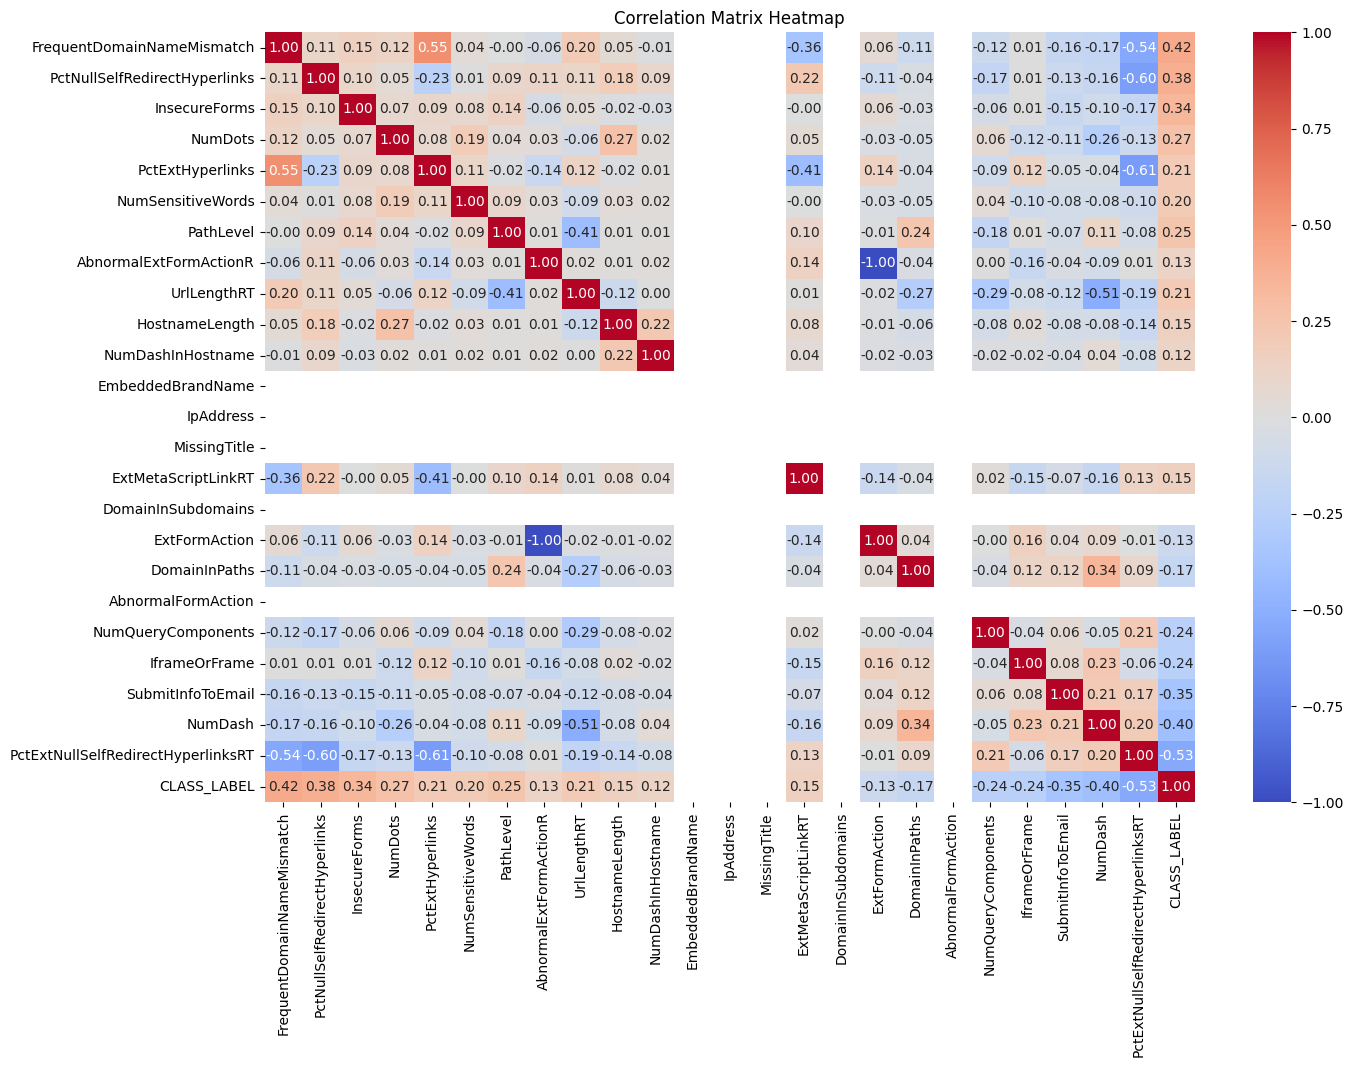

In [32]:
# Compute the correlation matrix
correlation_matrix = new_data.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

# Feature Importance Bar Chart

This bar chart highlights the top features contributing to the Random Forest model's predictions. Each bar represents a feature's importance, with higher bars indicating greater influence on classification accuracy. This visualization helps pinpoint the most critical predictors for identifying phishing emails.

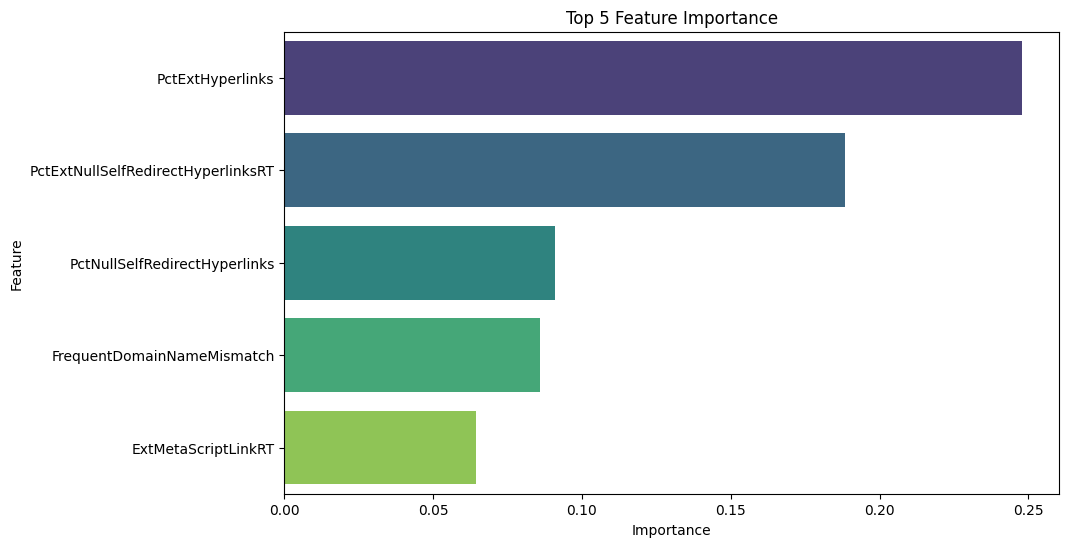

In [33]:
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the bar chart for the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(5), x='Importance', y='Feature', hue='Feature', palette='viridis', dodge=False, legend=False)
plt.title("Top 5 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
